In [70]:
import os
import numpy as np
import pandas as pd
import torch
import random

import sys
sys.path.append('/home/wergillius/Project/TIGON')
import utility 
from importlib import reload

from matplotlib import pyplot as plt
import seaborn as sns


In [2]:
import scanpy as sc

# load data

In [3]:
# ad
data_path = "/home/wergillius/Project/HSPCdynamics/procdata/04script/"
ad = sc.read_h5ad(f"{data_path}/combined_filt.h5ad")


# cluster 7 meta
clu7_df = pd.read_csv("/home/wergillius/Project/HSPCdynamics/PD_model/clu_7/tables/table_all_parameters_clu_7.csv", index_col=0)
clu7_df['timepoint_tx_days'] = ad.obs.loc[clu7_df.index, 'timepoint_tx_days'].values
timepoints = np.sort(ad.obs['timepoint_tx_days'].unique()) 

# cellbarcode of z
CB_ay = np.load("../Input/HSPC_clu7_cellbarcode.npy", allow_pickle=True)
CBs = np.concatenate(CB_ay, axis=0)

# subset

clu7_ad = ad[CBs].copy()
clu7_ad.obs['dpt_pseudotime_scaled'] = clu7_df.loc[CBs, 'dpt_pseudotime_scaled']

In [52]:
timepoints = np.sort(ad.obs['timepoint_tx_days'].unique()) 

In [53]:
timepoints

array([  3,   7,  12,  27,  49,  76, 112, 161, 269])

In [5]:
clu7_ad

AnnData object with n_obs × n_vars = 8704 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

# construct Diffusion map coordis

In [6]:
DM_ay = [clu7_ad[cbs].obsm['DM_EigenVectors'] for cbs in CB_ay]
DM_ay = np.array(DM_ay, dtype='object')
np.save('/home/wergillius/Project/TIGON/Input/clu7_DiffMap.npy', DM_ay, allow_pickle=True)

In [54]:
DM_ay = np.load('/home/wergillius/Project/TIGON/Input/clu7_DiffMap.npy', allow_pickle=True)

In [7]:
for dm in DM_ay:
    print(dm.shape)

(99, 30)
(215, 30)
(190, 30)
(795, 30)
(667, 30)
(1152, 30)
(1754, 30)
(1315, 30)
(2517, 30)


# plot fun

In [119]:
def umap_by_time(color_col):
    fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
    # axs = axs.flatten()
    axis_j = 0

    for t in timepoints:
        cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

        sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[axis_j], alpha=0.5, s=50,frameon=False);
        sc.pl.umap(clu7_ad[cbs], color=color_col, alpha=0.7, color_map='viridis', 
                return_fig=False,show=False, ax=axs[axis_j], s=50, frameon=False, 
                title='scaled pseudotime d%d'%t);
        
        axis_j += 1

    return fig, axs

def plot_along_pseudotime(color_col):
    
    fig,axs = plt.subplots(2, 9, figsize=(30,4), dpi=100, gridspec_kw={'hspace':0.3})
    # axs = axs.flatten()
    axis_j = 0

    for t in timepoints:
        cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index

        sc.pl.umap(clu7_ad, show=False, return_fig=False,  ax=axs[0,axis_j], alpha=0.5, s=50,frameon=False);
        sc.pl.umap(clu7_ad[cbs], color=color_col, alpha=0.7, color_map='viridis', #colorbar_loc=None,
                return_fig=False,show=False, ax=axs[0, axis_j], s=50, frameon=False, 
                title='scaled pseudotime d%d'%t);


        axs[0,axis_j].invert_xaxis()

        sns.kdeplot(clu7_df.query('`timepoint_tx_days` == @t')['dpt_pseudotime_scaled'], label="d%d"%t, ax=axs[1,axis_j])
        sns.despine(ax=axs[1,axis_j])
        axs[1,axis_j].set_xlim(0,1)
        axs[1,axis_j].set_ylabel("")

        axis_j += 1

    axs[1,0].set_ylabel("density")
    axs[0,0].set_ylabel("UMAP-2")
    axs[0,0].set_xlabel("UMAP-1")
    fig.show()
    # axs[-1].axis("off")
    return fig

def scatter_density(color_col):
    fig,axs = plt.subplots(1, 9, figsize=(30,2), dpi=100, gridspec_kw={'wspace':0.3})
    # axs = axs.flatten()
    axis_j = 0

    for t in timepoints:
        cbs = clu7_ad.obs.query('`timepoint_tx_days` == @t').index
        sns.scatterplot(data=clu7_ad.obs.loc[cbs], x='dpt_pseudotime_scaled', y = color_col, ax=axs[axis_j])
        # sns.kdeplot(clu7_df.query('`timepoint_tx_days` == @t')['dpt_pseudotime_scaled'], label="d%d"%t, ax=axs[axis_j])
        
        axs[axis_j].set_xlim(0,1)
        sns.despine(ax=axs[axis_j])

        axis_j += 1
    return fig

# TIGON density

In [20]:
sigma = 0.5

In [65]:
# to Tensor
data_train=[]
for i in range(DM_ay.shape[0]):
    data_train.append(torch.from_numpy(DM_ay[i]).type(torch.float32).to('cuda:3'))

In [ ]:
time_pts = range(len(data_train))
leave_1_out = []
train_time = [x for i,x in enumerate(time_pts) if i!=leave_1_out]

In [67]:
TIGON_u = []


for i, dm in enumerate(DM_ay):
    dm_ts = torch.from_numpy(dm).type(torch.float32).to('cuda:3')
    with torch.no_grad():
        u = utility.MultimodalGaussian_density(dm_ts, train_time, i , data_train, sigma, device='cuda:3')
    TIGON_u.append(u.detach().cpu().numpy())

TIGON_u = np.concatenate(TIGON_u, axis=0)

In [68]:
clu7_ad.obs['TIGON_u_DM30'] = TIGON_u

In [69]:
# to Tensor
data_train_DM10 =[]
for i in range(DM_ay.shape[0]):
    data_train_DM10.append(torch.from_numpy(DM_ay[i][:,:10]).type(torch.float32).to('cuda:3'))

TIGON_u_DM10 = []

for i, dm in enumerate(DM_ay):
    dm_ts = torch.from_numpy(dm[:,:10]).type(torch.float32).to('cuda:3')
    with torch.no_grad():
        u = utility.MultimodalGaussian_density(dm_ts, train_time, i , data_train_DM10, sigma, device='cuda:3')
    TIGON_u_DM10.append(u.detach().cpu().numpy())

TIGON_u_DM10 = np.concatenate(TIGON_u_DM10, axis=0)

clu7_ad.obs['TIGON_u_DM10'] = TIGON_u_DM10

# Plot TIGON u

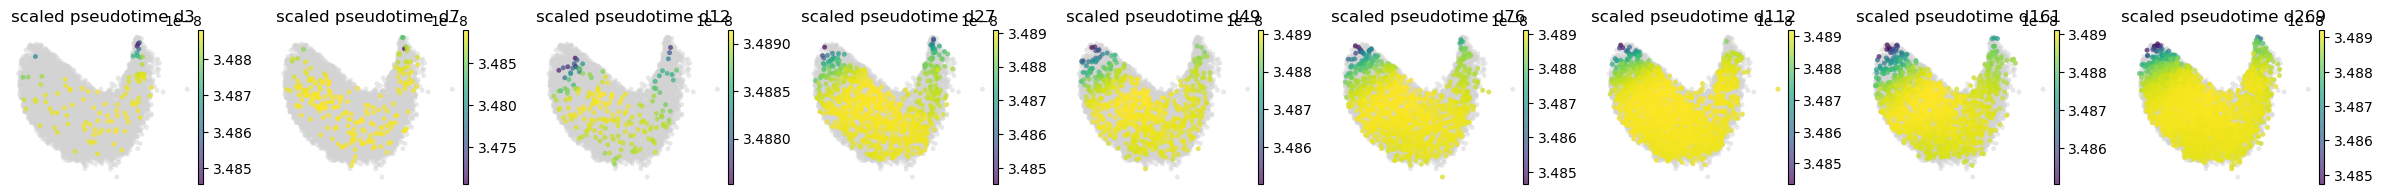

In [74]:
fig, axs = umap_by_time('TIGON_u_DM30')
fig

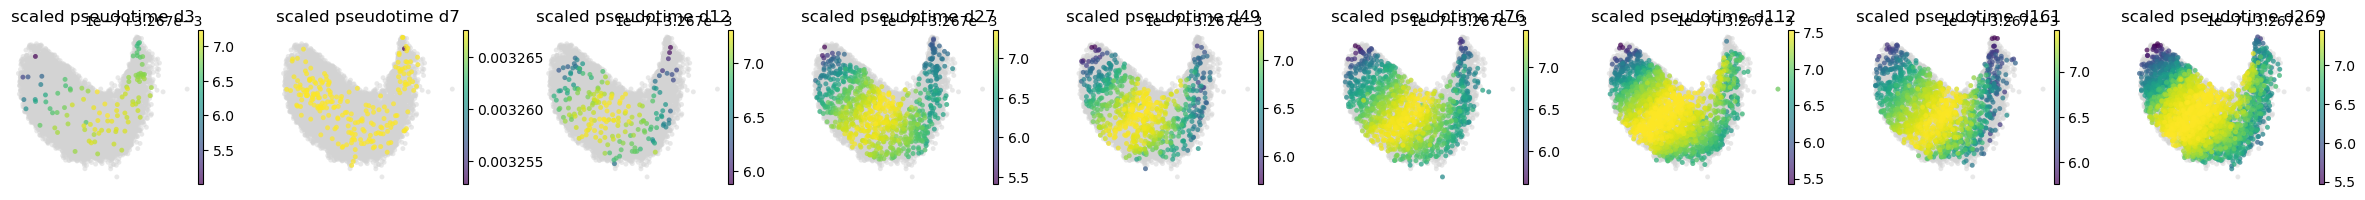

In [75]:
fig, axs = umap_by_time('TIGON_u_DM10')
fig

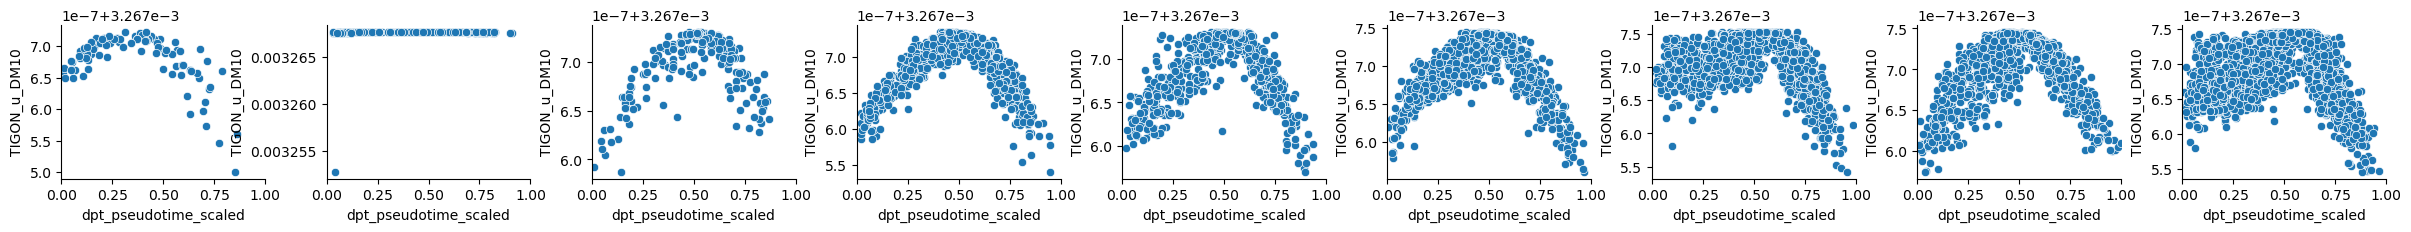

In [183]:
scatter_density('TIGON_u_DM10')

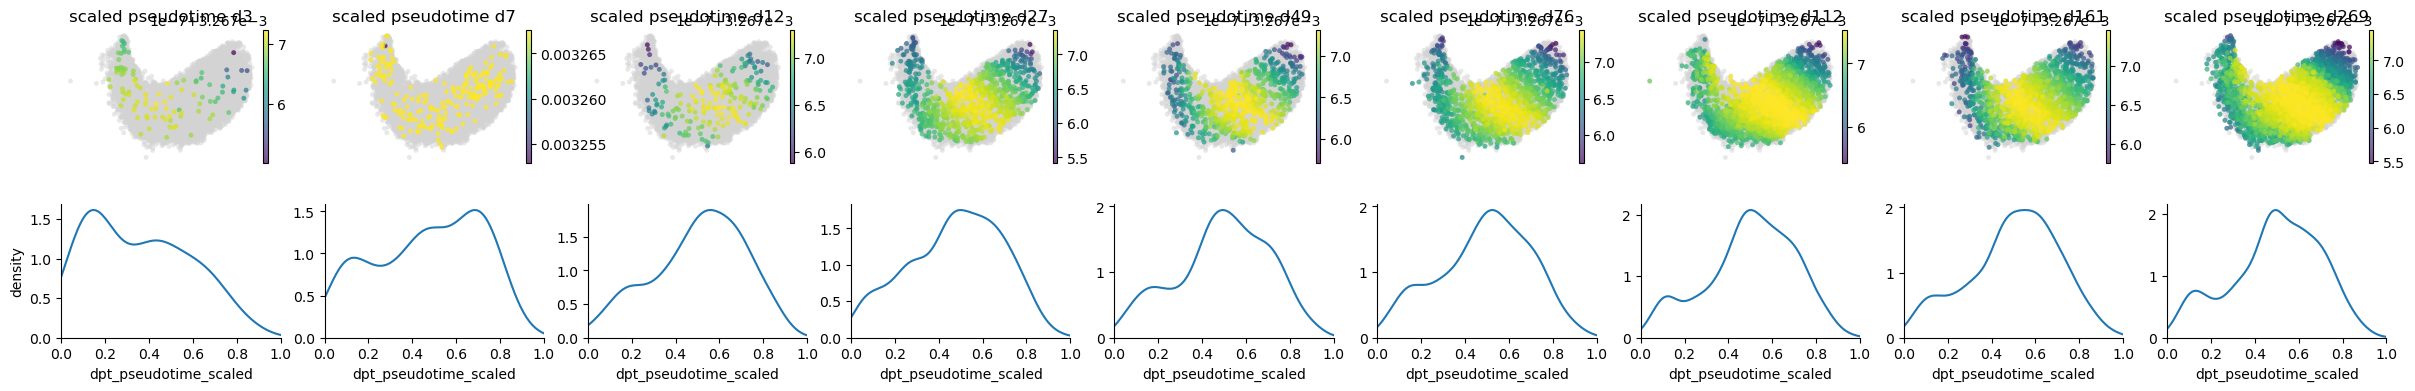

In [90]:
figg2 = plot_along_pseudotime('TIGON_u_DM10')
figg2

# guassian kde fn

In [36]:
from scipy.stats import gaussian_kde,entropy

In [76]:
gussian_kde_u = []

for dm in DM_ay:
    # print(pc.shape)
    kde_fn = gaussian_kde(dm.T, bw_method='silverman')       # take in [n_dim, n_sample]
    gussian_kde_u.append(kde_fn(dm.T))

gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)


In [77]:
clu7_ad.obs['gaussian_kde_u'] = gussian_kde_u

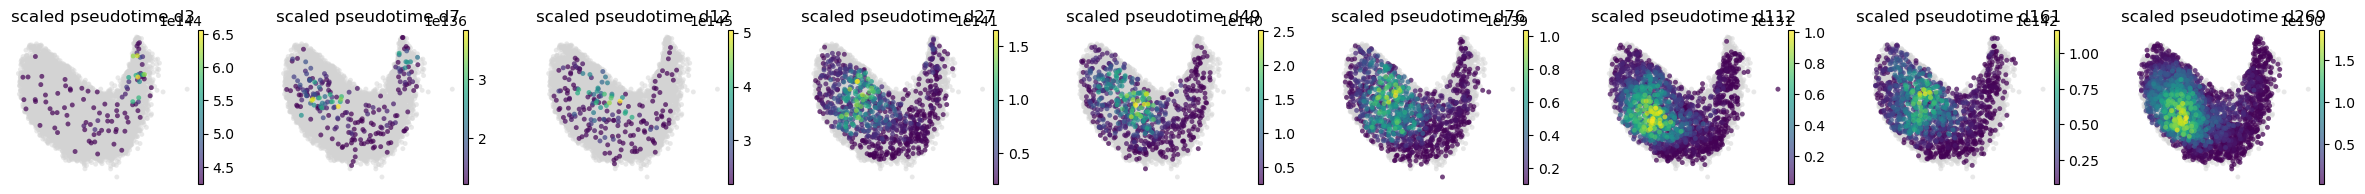

In [79]:
fig, axs = umap_by_time('gaussian_kde_u');
fig

In [101]:
import seaborn as sns

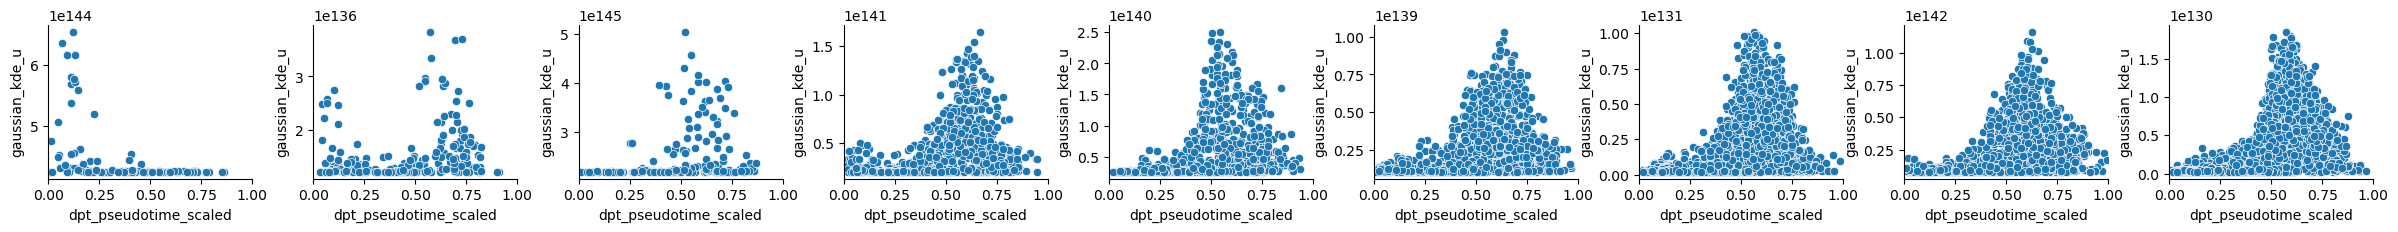

In [120]:
scatter_density('gaussian_kde_u')

In [81]:
gussian_kde_u = []

for dm in DM_ay:
    # print(pc.shape)
    kde_fn = gaussian_kde(dm[:,:10].T,  bw_method='silverman')       # take in [n_dim, n_sample]
    gussian_kde_u.append(kde_fn(dm[:,:10].T))

gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)

clu7_ad.obs['gaussian_kde_u_dm10'] = gussian_kde_u


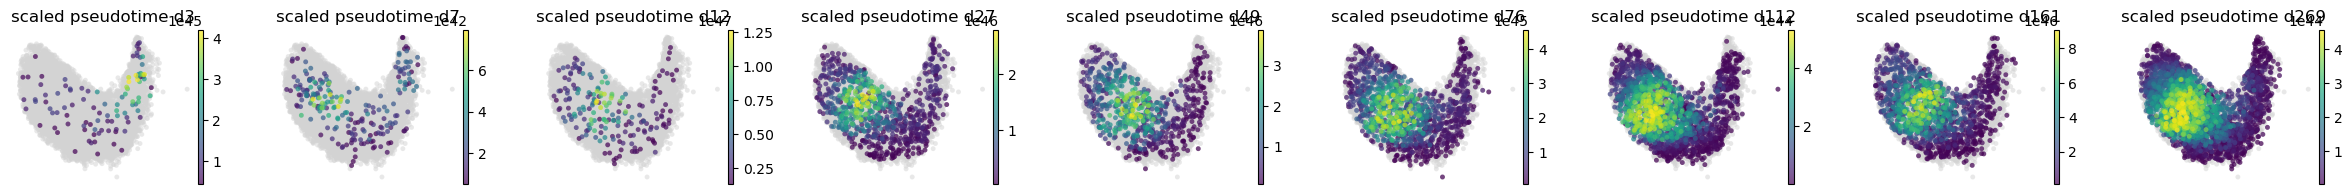

In [ ]:
fig, axs = umap_by_time('gaussian_kde_u_dm10');

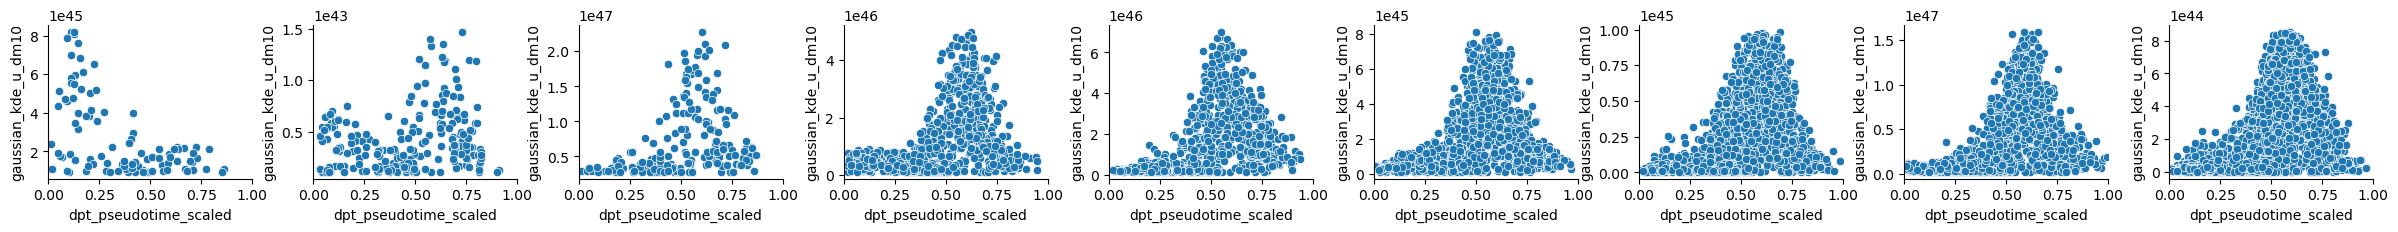

In [121]:
scatter_density('gaussian_kde_u_dm10')

# Efficient KDE

In [152]:
from efficient_kde.kde import FastLaplacianKDE, kde
bandwidth = 1
L = 90
# scale to 0-1
DM_x = ad.obsm['DM_EigenVectors']
DM_x_range = (DM_x.max(axis=0) - DM_x.min(axis=0)).reshape(-1,30)
norm_DMx = (DM_x - DM_x.min(axis=0)) / DM_x_range
ad.obsm['DM_EigenVectors_Scaled'] = norm_DMx

# calculate
DM_normed = [ad[cbs].obsm['DM_EigenVectors_Scaled'] for cbs in CB_ay]
dataset.shape
query.shape
hbe_u = []

for dm in DM_ay:
    # print(dm.shape)
    # kde_fn = gaussian_kde(dm.T, bw_method='silverman')       # take in [n_dim, n_sample]
    hbe = FastLaplacianKDE(dm, bandwidth=0.05, L=30)
    u_t = np.array([hbe.kde(dm[i,:]) for i in range(dm.shape[0])])
    hbe_u.append(u_t)

hbe_u = np.concatenate(hbe_u, axis=0)
clu7_ad.obs['hbe_u_dm30'] = hbe_u


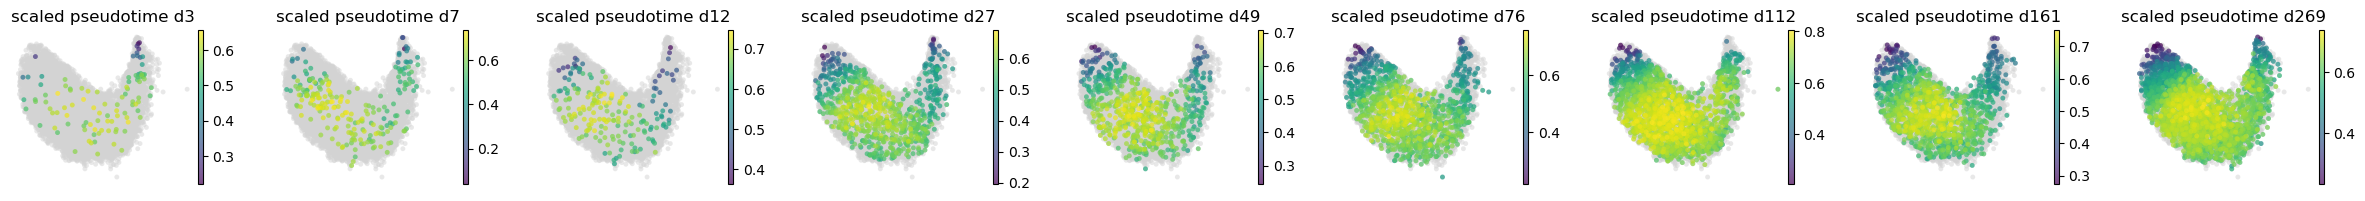

In [177]:
fig, axs = umap_by_time(color_col='hbe_u_dm30')
fig

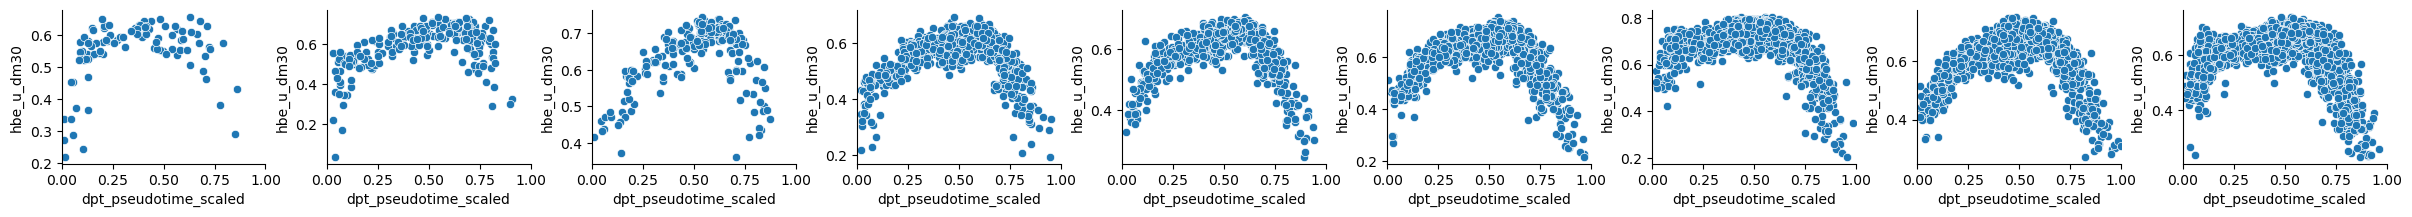

In [184]:
scatter_density("hbe_u_dm30")

In [178]:
hbe_u_dim10 = []

for dm in DM_ay:
    # print(dm.shape)
    # kde_fn = gaussian_kde(dm.T, bw_method='silverman')       # take in [n_dim, n_sample]
    hbe = FastLaplacianKDE(dm[:,:10], bandwidth=0.2, L=90)
    u_t = np.array([hbe.kde(dm[i,:10]) for i in range(dm.shape[0])])
    hbe_u_dim10.append(u_t)

hbe_u_dim10 = np.concatenate(hbe_u_dim10, axis=0)
clu7_ad.obs['hbe_u_dm10'] = hbe_u_dim10


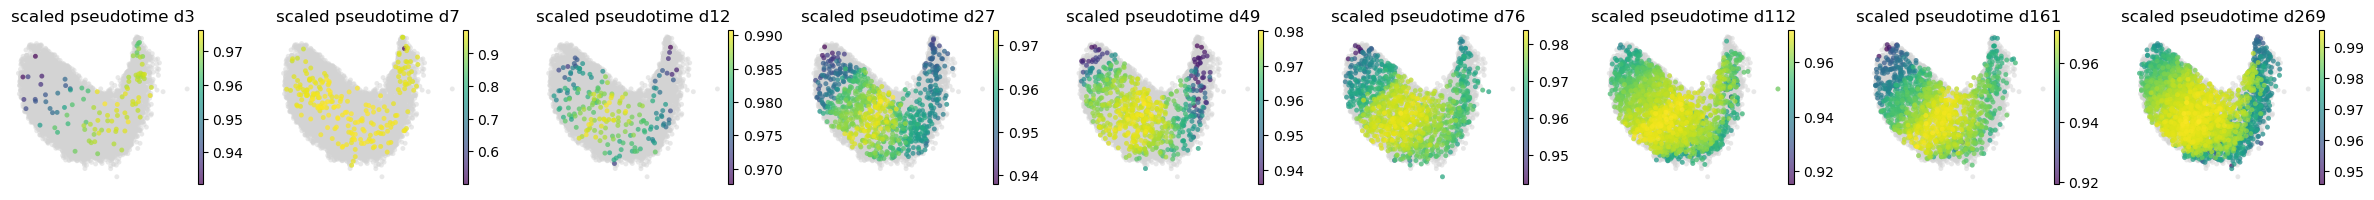

In [179]:
fig, axs = umap_by_time(color_col='hbe_u_dm10')
fig

# Denmarf KDE

In [50]:
from denmarf import DensityEstimate

In [51]:
save_dir = "/home/wergillius/Project/TIGON/Density/denmarf_pickle"

In [ ]:
de = DensityEstimate.from_file(filename="filename_for_the_model.pkl")

In [128]:
denmarf_u = []

for i, dm in enumerate(DM_ay):
    
    de = DensityEstimate.from_file(filename=f"{save_dir}/DiffMap10_day{timepoints[i]}th.pkl")
    u = np.exp(de.score_samples(dm[:,:10]))
    denmarf_u.append(u)


u_ay = np.concatenate(denmarf_u, axis=0)

clu7_ad.obs['denmarf_u_DM10'] =  np.clip(
        u_ay, *np.quantile(u_ay, [0.05, 1])
    )

In [124]:
denmarf_u = []

for i, dm in enumerate(DM_ay):
    
    de = DensityEstimate.from_file(filename=f"{save_dir}/DiffMap30_day{timepoints[i]}th.pkl")
    u = np.exp(de.score_samples(dm))
    denmarf_u.append(u)

u_ay = np.concatenate(denmarf_u, axis=0)

clu7_ad.obs['denmarf_u_DM30'] =  np.clip(
        u_ay, *np.quantile(u_ay, [0.05, 1])
    )

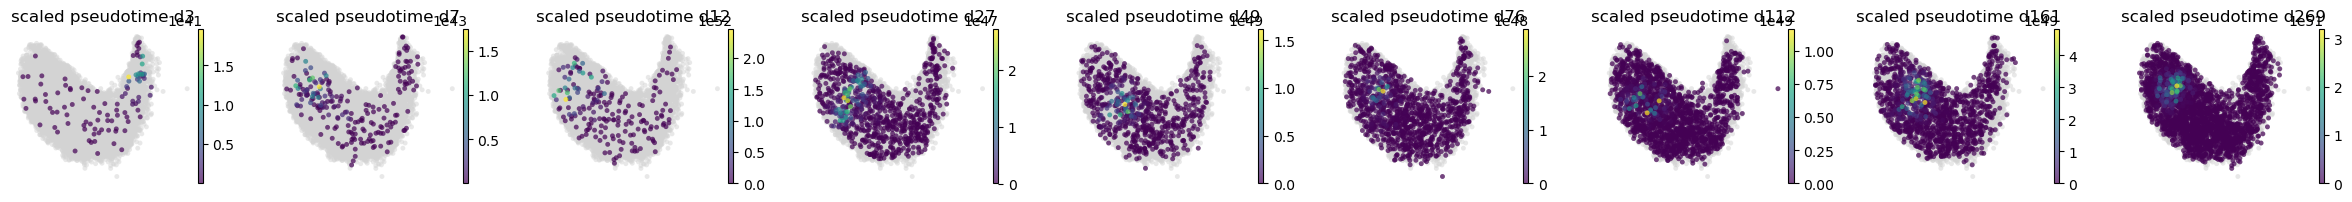

In [129]:
fig, axs = umap_by_time('denmarf_u_DM10')
fig

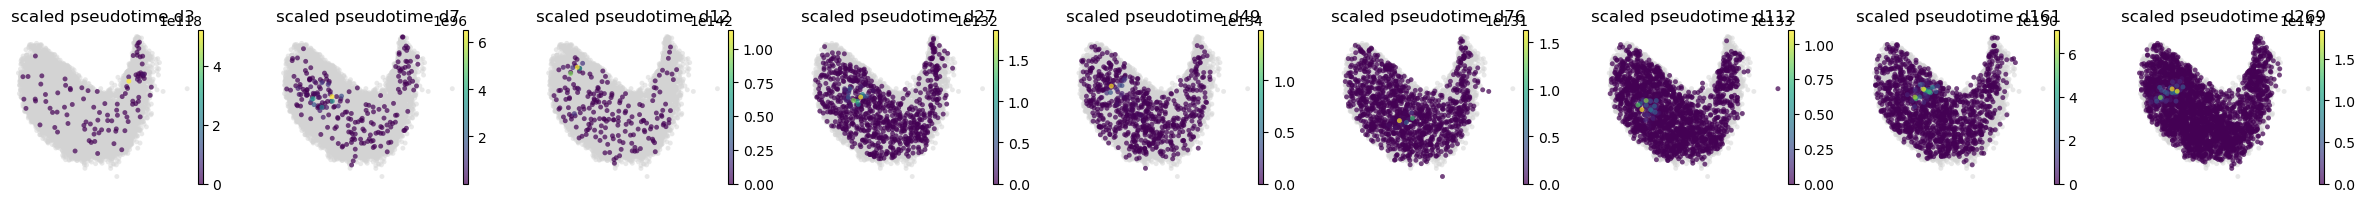

In [130]:
fig, axs = umap_by_time('denmarf_u_DM30')
fig

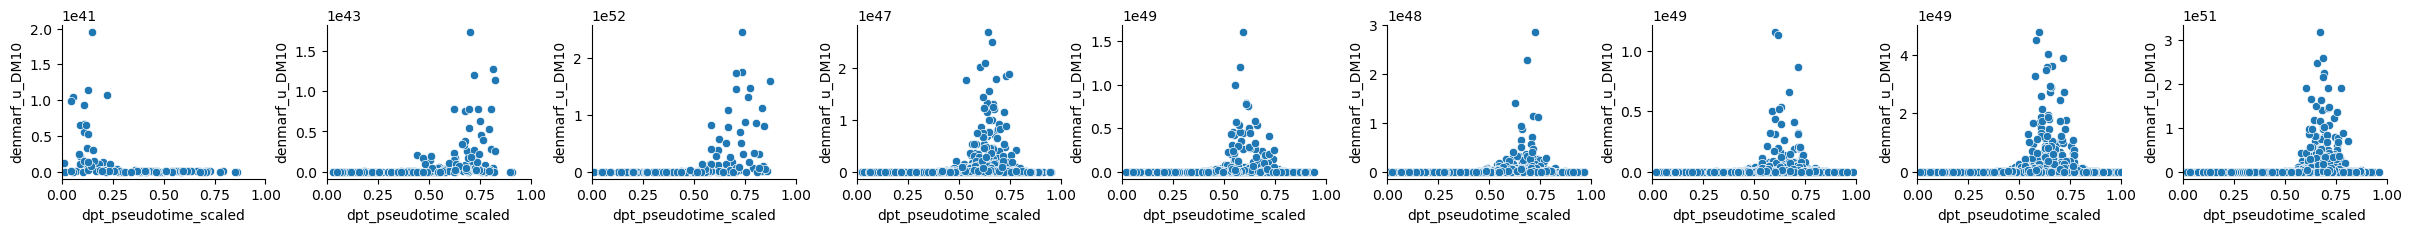

In [180]:
scatter_density('denmarf_u_DM10')

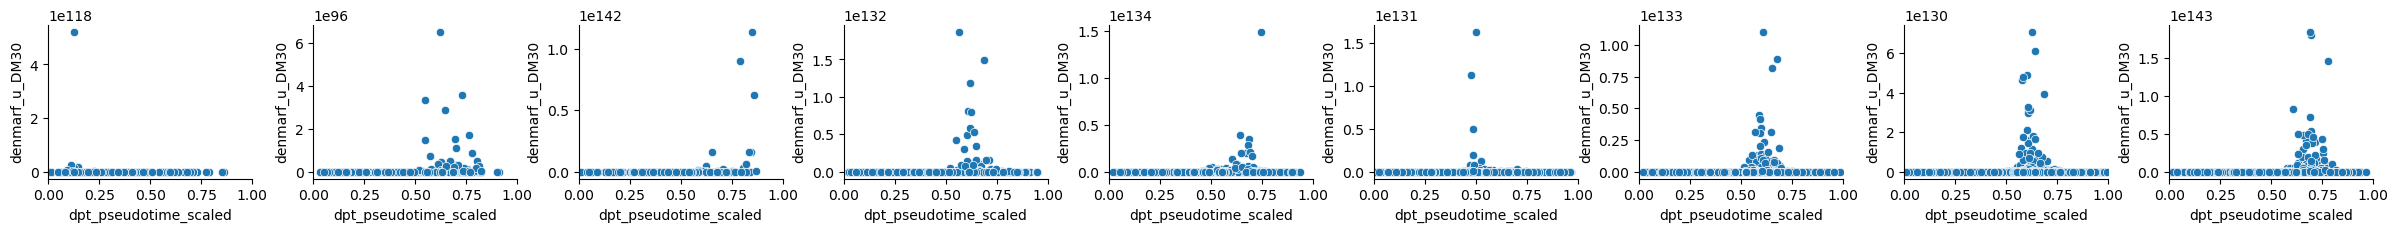

In [181]:
scatter_density('denmarf_u_DM30')

# save all to h5ad

In [182]:
clu7_ad.write_h5ad("clu7_DM_densityEst.h5ad")